
========== K-MEANS CLUSTERING ==========
Silhouette Score : 0.4450525692083638
Davies-Bouldin Score : 0.7675522686571644


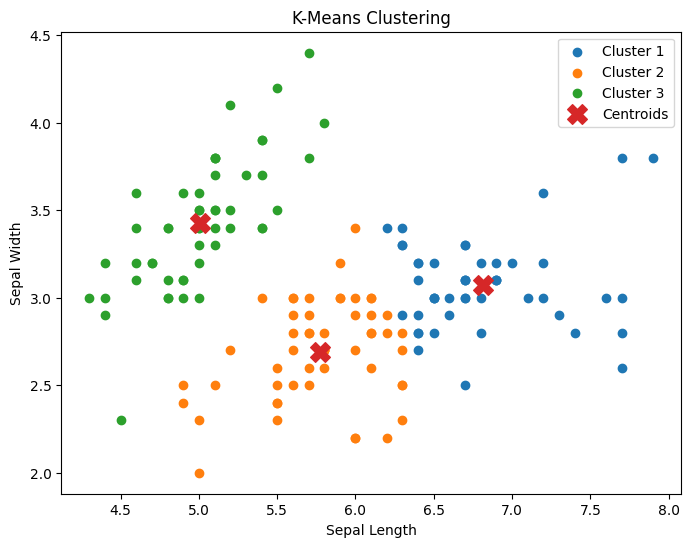


========== HIERARCHICAL CLUSTERING ==========
Silhouette Score : 0.3653346819163389
Davies-Bouldin Score : 0.8019006296926161


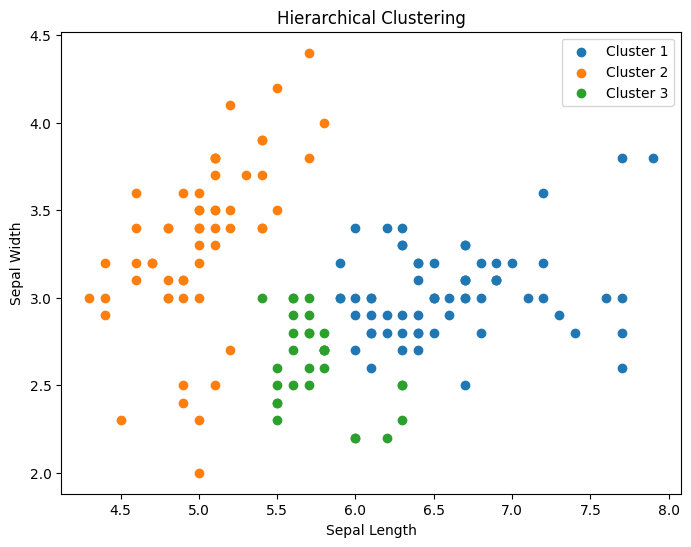

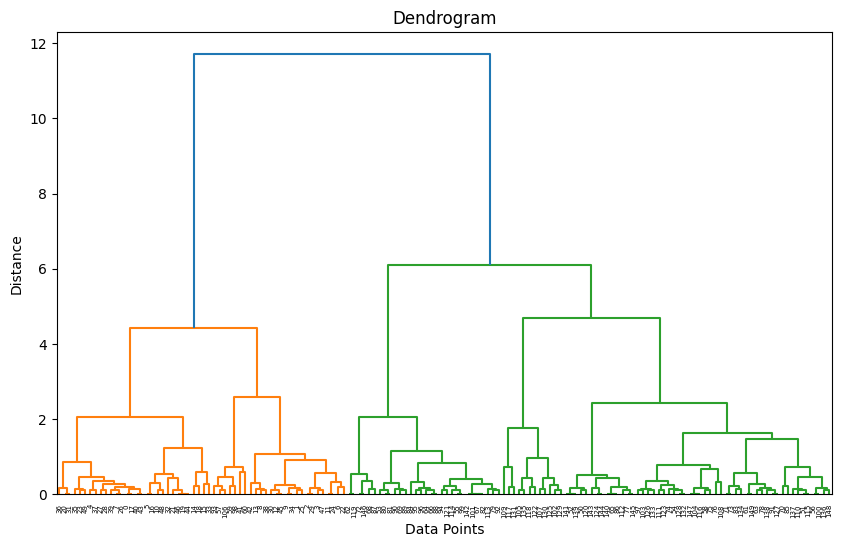

In [2]:
# ---------------------------------------------------
# Install Required Libraries
# ---------------------------------------------------

# pip install scikit-learn
# pip install matplotlib
# pip install scipy


# ---------------------------------------------------
# Import Libraries
# ---------------------------------------------------

from sklearn.datasets import load_iris

# Clustering Algorithms
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering

# Evaluation Scores
from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score

# Visualization
import matplotlib.pyplot as plt

# Dendrogram
from scipy.cluster.hierarchy import dendrogram, linkage


# ---------------------------------------------------
# Load Iris Dataset
# ---------------------------------------------------

iris = load_iris()

# Features
X = iris.data

# Use only first two features for visualization
X = X[:, :2]


# ===================================================
# K-MEANS CLUSTERING
# ===================================================

print("\n========== K-MEANS CLUSTERING ==========")

# Create KMeans model
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

# Fit and predict clusters
kmeans_labels = kmeans.fit_predict(X)


# ---------------------------------------------------
# Evaluation Scores
# ---------------------------------------------------

# Silhouette Score
kmeans_silhouette = silhouette_score(X, kmeans_labels)

# Davies-Bouldin Score
kmeans_db = davies_bouldin_score(X, kmeans_labels)

# Print Scores
print("Silhouette Score :", kmeans_silhouette)
print("Davies-Bouldin Score :", kmeans_db)


# ---------------------------------------------------
# K-Means Visualization
# ---------------------------------------------------

plt.figure(figsize=(8,6))

# Plot each cluster separately
for cluster in range(3):

    plt.scatter(
        X[kmeans_labels == cluster, 0],
        X[kmeans_labels == cluster, 1],
        label=f'Cluster {cluster + 1}'
    )

# Plot centroids
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    marker='X',
    s=200,
    label='Centroids'
)

# Labels
plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")

# Title
plt.title("K-Means Clustering")

# Legend
plt.legend()

plt.show()


# ===================================================
# HIERARCHICAL CLUSTERING
# ===================================================

print("\n========== HIERARCHICAL CLUSTERING ==========")

# Create Hierarchical model
hc = AgglomerativeClustering(
    n_clusters=3
)

# Predict clusters
hc_labels = hc.fit_predict(X)


# ---------------------------------------------------
# Evaluation Scores
# ---------------------------------------------------

# Silhouette Score
hc_silhouette = silhouette_score(X, hc_labels)

# Davies-Bouldin Score
hc_db = davies_bouldin_score(X, hc_labels)

# Print Scores
print("Silhouette Score :", hc_silhouette)
print("Davies-Bouldin Score :", hc_db)


# ---------------------------------------------------
# Hierarchical Clustering Visualization
# ---------------------------------------------------

plt.figure(figsize=(8,6))

# Plot each cluster separately
for cluster in range(3):

    plt.scatter(
        X[hc_labels == cluster, 0],
        X[hc_labels == cluster, 1],
        label=f'Cluster {cluster + 1}'
    )

# Labels
plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")

# Title
plt.title("Hierarchical Clustering")

# Legend
plt.legend()

plt.show()


# ===================================================
# DENDROGRAM
# ===================================================

# Generate linkage matrix
linked = linkage(X, method='ward')

plt.figure(figsize=(10,6))

# Plot dendrogram
dendrogram(linked)

# Labels
plt.title("Dendrogram")

plt.xlabel("Data Points")

plt.ylabel("Distance")

plt.show()